In [1]:
# 1) Setup & Imports
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils import resample

from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC, SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
FEATURE_DIR = Path(r"C:\Users\buck\Napplee\StressClassification\data\features")
FEATURE_FILE = FEATURE_DIR / "features_hrv.csv"
ARTIFACTS_DIR = Path("artifacts")
REPORTS_DIR = Path("reports")

for p in [FEATURE_DIR, ARTIFACTS_DIR, REPORTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print(f"Feature file: {FEATURE_FILE}")
print(f"Artifacts directory: {ARTIFACTS_DIR.resolve()}")

Feature file: C:\Users\buck\Napplee\StressClassification\data\features\features_hrv.csv
Artifacts directory: C:\Users\buck\Napplee\StressClassification\artifacts


## Part A — Classical ML on extracted features
- Dùng các feature HRV/engineered (`features_hrv.csv`) để train các mô hình ML (RandomForest, SVM, Logistic, ...).
- Đây là nhánh "ML" như bạn yêu cầu.

In [3]:
LABEL_CANDIDATES = ["label", "Label", "stress", "stress_level", "target", "class"]

def find_label_column(df_in: pd.DataFrame):
    for c in LABEL_CANDIDATES:
        if c in df_in.columns:
            return c
    return None

def standardize_features_df(df_in: pd.DataFrame) -> pd.DataFrame:
    out = df_in.copy()
    out = out.loc[:, ~out.columns.astype(str).str.startswith("Unnamed:")].copy()

    label_col = find_label_column(out)
    if label_col is None:
        raise ValueError(
            "Khong tim thay cot label trong feature dataset. Can mot trong cac cot: "
            + ", ".join(LABEL_CANDIDATES)
        )
    if label_col != "label":
        out = out.rename(columns={label_col: "label"})

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Feature dataset rong sau khi loai bo dong thieu label.")

    if "source_file" not in out.columns:
        out["source_file"] = "precomputed_features"
    if "window_id" not in out.columns:
        out["window_id"] = np.arange(len(out))

    if out["label"].dtype == "O" or str(out["label"].dtype).startswith("category"):
        out["label"] = out["label"].astype(str).str.strip()
    else:
        out["label"] = pd.to_numeric(out["label"], errors="coerce")

    out = out.dropna(subset=["label"]).copy()
    if out.empty:
        raise ValueError("Khong con mau nao sau khi chuan hoa cot label.")

    return out

if not FEATURE_FILE.exists():
    raise FileNotFoundError(f"Missing feature file: {FEATURE_FILE}")

features_df = pd.read_csv(FEATURE_FILE)
features_df = standardize_features_df(features_df)

# Ensure Stroop-derived features exist
if {'lf_power', 'hf_power'}.issubset(features_df.columns):
    denom = features_df['lf_power'].fillna(0) + features_df['hf_power'].fillna(0)
    with np.errstate(divide='ignore', invalid='ignore'):
        features_df['lf_nu'] = np.where(denom > 0, (features_df['lf_power'] / denom) * 100.0, np.nan)
        features_df['hf_nu'] = np.where(denom > 0, (features_df['hf_power'] / denom) * 100.0, np.nan)
if {'pnn50', 'n_peaks'}.issubset(features_df.columns) and 'nn50_count' not in features_df.columns:
    rr_count = features_df['n_peaks'].clip(lower=1) - 1
    features_df['nn50_count'] = np.round((features_df['pnn50'] / 100.0) * rr_count).astype('float')

print(f"Feature shape: {features_df.shape}")
print("Class distribution (label):")
print(features_df["label"].value_counts(dropna=False).sort_index())
display(features_df.head())

Feature shape: (480, 28)
Class distribution (label):
label
0    218
1    124
2     76
3     62
Name: count, dtype: int64


,source_file,window_id,window_start,window_end,label,mean_rr_ms,median_rr_ms,sdnn_ms,rmssd_ms,pnn50,...,voltage_max,voltage_skew,voltage_kurtosis,lf_power,hf_power,lf_hf_ratio,total_power,lf_nu,hf_nu,nn50_count
0,day_custom_segments_001.csv,0,0.0,1800.0,0,692.462846,683.59375,92.076921,61.924494,32.371055,...,1.060150,1.170468,2.523055,4640.963850,3833.309284,1.210694,8475.770861,54.765332,45.234668,841.0
1,day_custom_segments_001.csv,1,1800.0,3600.0,0,674.935824,660.15625,96.415759,61.244377,28.893058,...,1.058452,1.164108,2.500706,4499.270551,3653.571896,1.231472,8153.623787,55.186526,44.813474,770.0
2,day_custom_segments_001.csv,2,3600.0,5400.0,0,722.557417,722.65625,101.599960,68.132995,37.967055,...,1.056067,1.161323,2.518399,5372.432183,4597.086896,1.168660,9970.743382,53.888579,46.111421,945.0
3,day_custom_segments_001.csv,3,5400.0,7200.0,0,700.805284,691.40625,90.059851,64.607337,34.008570,...,1.057110,1.170998,2.530025,4815.753694,4103.019698,1.173710,8921.833030,53.995695,46.004305,873.0
4,day_custom_segments_001.csv,4,7200.0,9000.0,0,710.989995,703.12500,100.130544,64.885411,36.378015,...,1.059383,1.160634,2.515182,5009.315616,4352.665226,1.150862,9363.600626,53.507006,46.492994,920.0


Feature dataset preview:


,source_file,window_id,window_start,window_end,label,mean_rr_ms,median_rr_ms,sdnn_ms,rmssd_ms,pnn50,...,voltage_max,voltage_skew,voltage_kurtosis,lf_power,hf_power,lf_hf_ratio,total_power,lf_nu,hf_nu,nn50_count
0,day_custom_segments_001.csv,0,0.0,1800.0,0,692.462846,683.59375,92.076921,61.924494,32.371055,...,1.060150,1.170468,2.523055,4640.963850,3833.309284,1.210694,8475.770861,54.765332,45.234668,841.0
1,day_custom_segments_001.csv,1,1800.0,3600.0,0,674.935824,660.15625,96.415759,61.244377,28.893058,...,1.058452,1.164108,2.500706,4499.270551,3653.571896,1.231472,8153.623787,55.186526,44.813474,770.0
2,day_custom_segments_001.csv,2,3600.0,5400.0,0,722.557417,722.65625,101.599960,68.132995,37.967055,...,1.056067,1.161323,2.518399,5372.432183,4597.086896,1.168660,9970.743382,53.888579,46.111421,945.0
3,day_custom_segments_001.csv,3,5400.0,7200.0,0,700.805284,691.40625,90.059851,64.607337,34.008570,...,1.057110,1.170998,2.530025,4815.753694,4103.019698,1.173710,8921.833030,53.995695,46.004305,873.0
4,day_custom_segments_001.csv,4,7200.0,9000.0,0,710.989995,703.12500,100.130544,64.885411,36.378015,...,1.059383,1.160634,2.515182,5009.315616,4352.665226,1.150862,9363.600626,53.507006,46.492994,920.0



Describe numeric features:


,count,mean,std,min,25%,50%,75%,max
window_id,480.0,23.500000,13.867852,0.000000,11.750000,23.500000,35.250000,47.000000
window_start,480.0,42300.000000,24962.134163,0.000000,21150.000000,42300.000000,63450.000000,84600.000000
window_end,480.0,44100.000000,24962.134163,1800.000000,22950.000000,44100.000000,65250.000000,86400.000000
label,480.0,0.962500,1.063069,0.000000,0.000000,1.000000,2.000000,3.000000
mean_rr_ms,480.0,672.572071,27.966256,590.005123,654.855165,672.277082,691.122357,755.855274
median_rr_ms,480.0,664.310710,29.636096,582.031250,644.531250,664.062500,683.593750,750.000000
sdnn_ms,480.0,84.711752,9.702320,53.719164,77.920548,85.142345,91.361573,117.526289
rmssd_ms,480.0,55.136839,8.062936,30.138296,50.150626,55.695491,60.490377,77.542764
pnn50,480.0,24.435827,7.063339,5.575599,19.550457,24.957516,29.655049,42.326939
heart_rate_bpm,480.0,89.364588,3.737494,79.380276,86.815308,89.248915,91.623313,101.694032


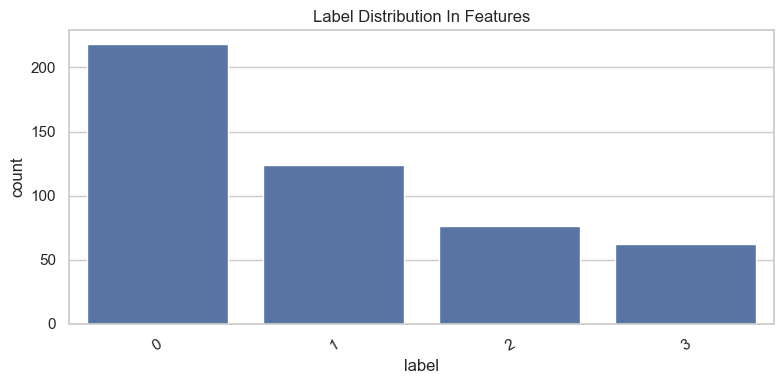

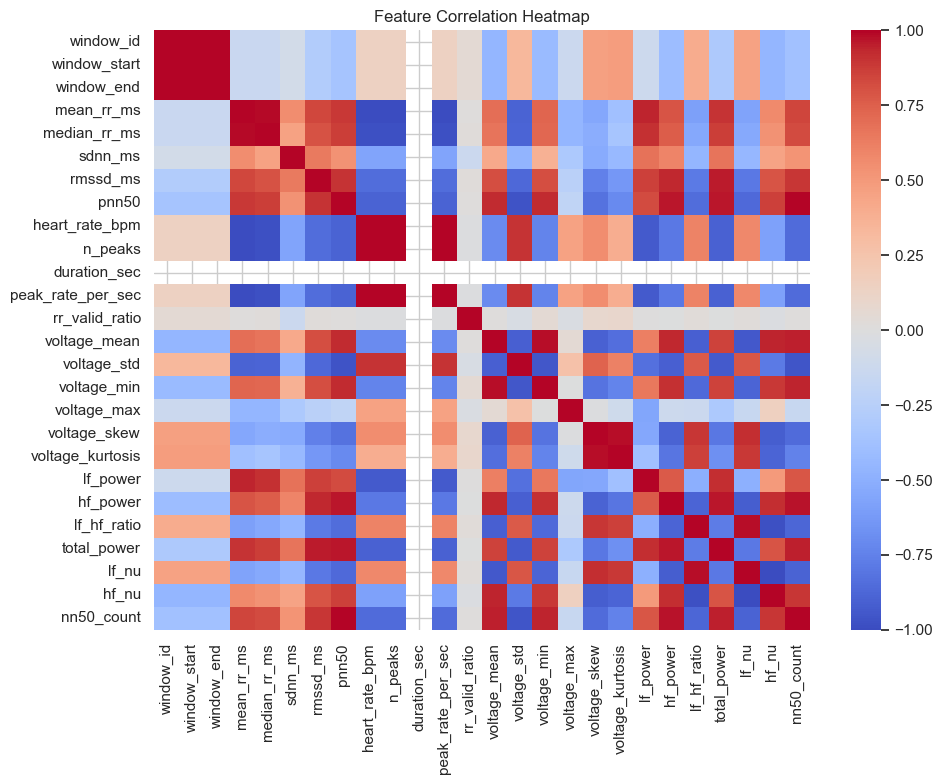

In [4]:
if "label" not in features_df.columns:
    raise ValueError("Khong co cot label trong features_df de train classifier.")

print("Feature dataset preview:")
display(features_df.head())

print("\nDescribe numeric features:")
display(features_df.describe(include=[np.number]).T.head(20))

plt.figure(figsize=(8, 4))
sns.countplot(data=features_df, x="label", order=features_df["label"].value_counts().index)
plt.title("Label Distribution In Features")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

num_cols = [c for c in features_df.select_dtypes(include=[np.number]).columns if c != "label"]
if len(num_cols) >= 2:
    plt.figure(figsize=(10, 8))
    sns.heatmap(features_df[num_cols].corr(numeric_only=True), cmap="coolwarm", center=0)
    plt.title("Feature Correlation Heatmap")
    plt.tight_layout()
    plt.show()

In [5]:
EXPERIMENT_MODE = 'all'  # options: 'all', 'pure_only'
data_model = features_df.copy()
if EXPERIMENT_MODE == 'pure_only' and 'source_file' in data_model.columns:
    src_lower = data_model['source_file'].astype(str).str.lower()
    data_model = data_model[src_lower.str.contains('pure')].copy()
    print(f"Experiment mode: {EXPERIMENT_MODE} -> rows={len(data_model)}")
elif EXPERIMENT_MODE == 'all':
    print(f"Experiment mode: {EXPERIMENT_MODE} -> rows={len(data_model)}")
else:
    print(f"Experiment mode {EXPERIMENT_MODE} khong hop le hoac thieu source_file. Dung toan bo du lieu.")

# Cot giu de trace/ID, khong dua vao feature train
leakage_or_trace_cols = [c for c in ["source_file", "window_id"] if c in data_model.columns]
groups = data_model["source_file"].astype(str).values if "source_file" in data_model.columns else None

X = data_model.drop(columns=["label"] + leakage_or_trace_cols)
y_raw = data_model["label"]

if y_raw.nunique(dropna=True) < 2:
    raise ValueError("Target label chi co 1 lop, khong the train classifier.")

FEATURE_SET_MODE = "all_numeric"  # options: 'hrv_core', 'stroop', 'all_numeric'
HRV_CORE_FEATURES = ["sdnn_ms", "rmssd_ms", "pnn50", "lf_hf_ratio"]
STROOP_FEATURES = [
    "mean_rr_ms",
    "heart_rate_bpm",
    "sdnn_ms",
    "rmssd_ms",
    "nn50_count",
    "pnn50",
    "lf_nu",
    "hf_nu",
    "lf_hf_ratio",
]

if FEATURE_SET_MODE == "hrv_core":
    SELECTED_FEATURES = [f for f in HRV_CORE_FEATURES if f in X.columns]
elif FEATURE_SET_MODE == "stroop":
    SELECTED_FEATURES = [f for f in STROOP_FEATURES if f in X.columns]
else:
    # Prefer all numeric signal features (excluding obvious leakage columns removed above).
    SELECTED_FEATURES = X.select_dtypes(include=[np.number]).columns.tolist()

if not SELECTED_FEATURES:
    raise ValueError("Khong tim thay feature nao de train.")

# Loai bo cot co qua nhieu missing neu co
missing_ratio = X[SELECTED_FEATURES].isna().mean()
SELECTED_FEATURES = [f for f in SELECTED_FEATURES if missing_ratio[f] <= 0.40]
if not SELECTED_FEATURES:
    raise ValueError("Tat ca feature bi loai do missing ratio qua cao.")

# Chi su dung feature theo che do da chon
X = X[SELECTED_FEATURES].copy()

label_encoder = None
if y_raw.dtype == "O" or str(y_raw.dtype).startswith("category"):
    label_encoder = LabelEncoder()
    y = label_encoder.fit_transform(y_raw.astype(str))
    class_names = label_encoder.classes_.tolist()
    print(f"LabelEncoder applied. Classes: {class_names}")
else:
    y = y_raw.astype(int).values
    class_names = sorted(pd.Series(y).dropna().unique().tolist())

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

if len(numeric_features) + len(categorical_features) == 0:
    raise ValueError("Khong con feature hop le de train sau khi loai leakage columns.")

print(f"Modeling samples: {len(X)}")
print(f"Target classes: {class_names}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Categorical features: {len(categorical_features)}")
print(f"Feature mode: {FEATURE_SET_MODE}")
print(f"Features used ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")
if groups is not None:
    print(f"Unique groups (source_file): {pd.Series(groups).nunique()}")

# Data-first gate: chi khi du lieu on dinh moi nen focus tuning model
label_counts = pd.Series(y).value_counts()
label_imbalance_ratio = float(label_counts.max() / max(label_counts.min(), 1))
n_unique_sources = int(pd.Series(groups).nunique()) if groups is not None else 0
DATA_QUALITY_READY = (len(X) >= 1200) and (label_imbalance_ratio <= 1.50) and (n_unique_sources >= 80)
print(f"Data gate -> n_samples={len(X)}, imbalance={label_imbalance_ratio:.3f}, unique_sources={n_unique_sources}")
print(f"DATA_QUALITY_READY: {DATA_QUALITY_READY}")

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop",
)

feature_columns = X.columns.tolist()
print(f"Feature columns ({len(feature_columns)}): {feature_columns}")
print(f"Feature matrix shape: {X.shape}")

Experiment mode: all -> rows=480
Modeling samples: 480
Target classes: [0, 1, 2, 3]
Numeric features: 25
Categorical features: 0
Feature mode: all_numeric
Features used (25): ['window_start', 'window_end', 'mean_rr_ms', 'median_rr_ms', 'sdnn_ms', 'rmssd_ms', 'pnn50', 'heart_rate_bpm', 'n_peaks', 'duration_sec', 'peak_rate_per_sec', 'rr_valid_ratio', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'voltage_skew', 'voltage_kurtosis', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_power', 'lf_nu', 'hf_nu', 'nn50_count']
Unique groups (source_file): 10
Data gate -> n_samples=480, imbalance=3.516, unique_sources=10
DATA_QUALITY_READY: False
Feature columns (25): ['window_start', 'window_end', 'mean_rr_ms', 'median_rr_ms', 'sdnn_ms', 'rmssd_ms', 'pnn50', 'heart_rate_bpm', 'n_peaks', 'duration_sec', 'peak_rate_per_sec', 'rr_valid_ratio', 'voltage_mean', 'voltage_std', 'voltage_min', 'voltage_max', 'voltage_skew', 'voltage_kurtosis', 'lf_power', 'hf_power', 'lf_hf_ratio', 'total_po

In [6]:
y_series = pd.Series(y)
n_samples = len(X)

if n_samples < 2:
    raise ValueError(
        "So mau sau buoc feature extraction qua it (<2), khong the split train/test."
    )

if y_series.nunique() < 2:
    raise ValueError(
        "Target chi co 1 lop trong du lieu modeling, khong the train classifier."
    )

class_counts = y_series.value_counts()
can_stratify = class_counts.min() >= 2 and y_series.nunique() > 1 and n_samples >= 4

def pick_best_group_split(X_in, y_in, groups_in, test_size=0.2, n_trials=40):
    best = None
    best_score = -1.0
    y_all = pd.Series(y_in)
    global_dist = y_all.value_counts(normalize=True).sort_index()

    for seed in range(RANDOM_STATE, RANDOM_STATE + n_trials):
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
        tr_idx, te_idx = next(gss.split(X_in, y_in, groups=groups_in))
        y_te = pd.Series(y_in[te_idx])
        dist_te = y_te.value_counts(normalize=True).sort_index()

        # Bo qua split neu thieu lop trong test
        if dist_te.shape[0] < global_dist.shape[0]:
            continue

        # Score cao neu phan bo test gan phan bo global va min class ratio cao
        aligned = pd.concat([global_dist, dist_te], axis=1).fillna(0.0)
        aligned.columns = ["global", "test"]
        l1_gap = (aligned["global"] - aligned["test"]).abs().sum()
        min_ratio = float(dist_te.min())
        score = (1.0 - l1_gap) + min_ratio

        if score > best_score:
            best_score = score
            best = (tr_idx, te_idx, seed, dist_te)

    return best

groups_train = None
use_group_split = groups is not None and pd.Series(groups).nunique() >= 10
if use_group_split:
    picked = pick_best_group_split(X, y, groups, test_size=0.2, n_trials=60)
    if picked is None:
        print("Canh bao: khong tim duoc group split can bang. Quay ve split group mac dinh.")
        gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
        train_idx, test_idx = next(gss.split(X, y, groups=groups))
        split_seed = RANDOM_STATE
        test_dist = pd.Series(y[test_idx]).value_counts(normalize=True).sort_index()
    else:
        train_idx, test_idx, split_seed, test_dist = picked

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()
    y_train = y[train_idx]
    y_test = y[test_idx]
    groups_train = pd.Series(groups).iloc[train_idx].astype(str).to_numpy()
    print(f"Split mode: GroupShuffleSplit theo source_file (seed={split_seed}).")
    print("Class distribution in test (group split):")
    print(test_dist)
else:
    stratify_arg = y if can_stratify else None
    if not can_stratify:
        print("Canh bao: khong the stratify do co lop qua it mau. Se split khong stratify.")

    if n_samples == 2:
        test_size = 0.5
    elif n_samples == 3:
        test_size = 1 / 3
    else:
        test_size = 0.2

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=RANDOM_STATE,
        stratify=stratify_arg,
    )
    if groups is not None:
        groups_series = pd.Series(groups, index=X.index)
        groups_train = groups_series.loc[X_train.index].astype(str).to_numpy()
    print(f"Split mode: train_test_split, test_size={test_size}")

print(f"X_train: {X_train.shape}, y_train: {len(y_train)}")
print(f"X_test:  {X_test.shape}, y_test:  {len(y_test)}")
print("Class distribution in train (raw):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())

# Can bang nhe train set de ho tro cac model co ban
train_df = X_train.copy()
train_df["__target__"] = y_train
class_size = train_df["__target__"].value_counts().sort_index()
max_size = int(class_size.max())
min_size = int(class_size.min())
imbalance_ratio = (max_size / max(min_size, 1)) if len(class_size) else 1.0

if imbalance_ratio >= 2.5 and groups_train is None:
    balanced_parts = []
    for cls, n_cls in class_size.items():
        cls_df = train_df[train_df["__target__"] == cls]
        if n_cls < max_size:
            cls_df = resample(
                cls_df,
                replace=True,
                n_samples=max_size,
                random_state=RANDOM_STATE,
            )
        balanced_parts.append(cls_df)

    train_balanced = pd.concat(balanced_parts, axis=0, ignore_index=True)
    train_balanced = train_balanced.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    y_train = train_balanced["__target__"].to_numpy()
    X_train = train_balanced.drop(columns=["__target__"]).copy()
    groups_train = None
    print(f"Applied oversampling because imbalance_ratio={imbalance_ratio:.2f} >= 2.50")
else:
    if imbalance_ratio >= 2.5 and groups_train is not None:
        print(f"Skip oversampling because GroupKFold can bi vo do duplicate rows (imbalance_ratio={imbalance_ratio:.2f}).")
    perm = np.random.RandomState(RANDOM_STATE).permutation(len(X_train))
    X_train = X_train.iloc[perm].reset_index(drop=True)
    y_train = np.asarray(y_train)[perm]
    if groups_train is not None:
        groups_train = np.asarray(groups_train)[perm]
    print(f"Train shuffled without oversampling (imbalance_ratio={imbalance_ratio:.2f}).")

print(f"Final X_train: {X_train.shape}, y_train: {len(y_train)}")
print("Class distribution in train (final):")
print(pd.Series(y_train).value_counts(normalize=True).sort_index())
if groups_train is not None:
    print(f"Unique groups in train: {pd.Series(groups_train).nunique()}")

# Data-first augmentation: chi tao mau moi tren train, khong dong vao test
X_train_model = X_train.copy()
y_train_model = np.asarray(y_train).copy()
groups_train_model = np.asarray(groups_train).copy() if groups_train is not None else None

ENABLE_DATA_FIRST_AUGMENTATION = True
MIN_TRAIN_SAMPLES_TARGET = 1800 if EXPERIMENT_MODE == 'pure_only' else 960
AUG_NOISE_STD_RATIO = 0.02
AUG_CLIP_TO_CLASS_RANGE = True
n_synth_created = 0

if ENABLE_DATA_FIRST_AUGMENTATION and len(X_train_model) < MIN_TRAIN_SAMPLES_TARGET:
    rng = np.random.RandomState(RANDOM_STATE + 99)
    n_need = int(MIN_TRAIN_SAMPLES_TARGET - len(X_train_model))

    train_work = X_train_model.copy()
    train_work["__target__"] = y_train_model
    if groups_train_model is not None:
        train_work["__group__"] = groups_train_model

    numeric_cols_aug = train_work.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols_aug = [c for c in numeric_cols_aug if c != "__target__"]

    class_counts_aug = train_work["__target__"].value_counts().sort_index()
    alloc = {
        cls: int(np.floor(n_need * (cnt / class_counts_aug.sum())))
        for cls, cnt in class_counts_aug.items()
    }
    remaining = n_need - sum(alloc.values())
    for cls in class_counts_aug.sort_values(ascending=False).index.tolist():
        if remaining <= 0:
            break
        alloc[cls] += 1
        remaining -= 1

    class_stats = {}
    if numeric_cols_aug:
        for cls in class_counts_aug.index:
            cls_num = train_work.loc[train_work["__target__"] == cls, numeric_cols_aug]
            class_stats[cls] = {
                "min": cls_num.min(),
                "max": cls_num.max(),
                "std": cls_num.std(ddof=0).replace(0, 1e-6),
            }

    synth_X_parts = []
    synth_y_parts = []
    synth_g_parts = []

    for cls, n_new in alloc.items():
        if n_new <= 0:
            continue
        cls_rows = train_work[train_work["__target__"] == cls]
        sampled = cls_rows.sample(
            n=n_new,
            replace=True,
            random_state=int(rng.randint(0, 1_000_000)),
        ).reset_index(drop=True)

        if numeric_cols_aug:
            std_vec = class_stats[cls]["std"].values * AUG_NOISE_STD_RATIO
            noise = rng.normal(loc=0.0, scale=std_vec, size=(n_new, len(numeric_cols_aug)))
            sampled.loc[:, numeric_cols_aug] = sampled[numeric_cols_aug].to_numpy() + noise

            if AUG_CLIP_TO_CLASS_RANGE:
                mins = class_stats[cls]["min"]
                maxs = class_stats[cls]["max"]
                sampled.loc[:, numeric_cols_aug] = sampled[numeric_cols_aug].clip(lower=mins, upper=maxs, axis=1)

        drop_cols = ["__target__"] + (["__group__"] if "__group__" in sampled.columns else [])
        synth_X_parts.append(sampled.drop(columns=drop_cols))
        synth_y_parts.append(np.full(n_new, cls, dtype=y_train_model.dtype))
        if "__group__" in sampled.columns:
            synth_g_parts.append(sampled["__group__"].astype(str).to_numpy())

    if synth_X_parts:
        X_synth = pd.concat(synth_X_parts, axis=0, ignore_index=True)
        y_synth = np.concatenate(synth_y_parts)

        X_train_model = pd.concat([X_train_model, X_synth], axis=0, ignore_index=True)
        y_train_model = np.concatenate([y_train_model, y_synth])
        n_synth_created = int(len(X_synth))

        if groups_train_model is not None and synth_g_parts:
            g_synth = np.concatenate(synth_g_parts)
            groups_train_model = np.concatenate([groups_train_model.astype(str), g_synth])

perm_model = np.random.RandomState(RANDOM_STATE + 7).permutation(len(X_train_model))
X_train_model = X_train_model.iloc[perm_model].reset_index(drop=True)
y_train_model = y_train_model[perm_model]
if groups_train_model is not None:
    groups_train_model = np.asarray(groups_train_model)[perm_model]

print(f"Train samples for modeling (after data-first): {len(X_train_model)}")
print(f"Synthetic samples added: {n_synth_created}")
if groups_train_model is not None:
    print(f"Unique groups in modeling train: {pd.Series(groups_train_model).nunique()}")

Split mode: GroupShuffleSplit theo source_file (seed=43).
Class distribution in test (group split):
0    0.437500
1    0.270833
2    0.145833
3    0.145833
Name: proportion, dtype: float64
X_train: (384, 25), y_train: 384
X_test:  (96, 25), y_test:  96
Class distribution in train (raw):
0    0.458333
1    0.255208
2    0.161458
3    0.125000
Name: proportion, dtype: float64
Skip oversampling because GroupKFold can bi vo do duplicate rows (imbalance_ratio=3.67).
Train shuffled without oversampling (imbalance_ratio=3.67).
Final X_train: (384, 25), y_train: 384
Class distribution in train (final):
0    0.458333
1    0.255208
2    0.161458
3    0.125000
Name: proportion, dtype: float64
Unique groups in train: 8
Train samples for modeling (after data-first): 960
Synthetic samples added: 576
Unique groups in modeling train: 8


In [7]:
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures

def make_pipeline(model, extra_steps=None):
    steps = [("preprocessor", preprocessor)]
    if extra_steps:
        steps.extend(extra_steps)
    steps.append(("model", model))
    return Pipeline(steps=steps)

is_binary = len(np.unique(y_train_model)) == 2
TUNING_OBJECTIVE = "accuracy"
primary_scoring = TUNING_OBJECTIVE

# Focus profile: optimize only KNN, Logistic, RandomForest, SVM.
ENABLE_MODEL_TUNING = True
SECOND_PASS_TUNING = True

model_spaces = {
    "KNN_basic": {
        "extra_steps": [
            ("select", SelectKBest(score_func=f_classif, k=16)),
            # PCA step removed for speed
        ],
        "estimator": KNeighborsClassifier(
            n_neighbors=7,
            weights="distance",
            metric="minkowski",
            p=1,
            algorithm="brute",
            n_jobs=-1,
        ),
        "param_grid": ({
            "select__k": [12, 16, 20],
            # "pca__n_components": [None, 8, 12, 16], # Removed PCA from param_grid
            "model__n_neighbors": [5, 7, 9],
            "model__weights": ["distance"],
            "model__metric": ["minkowski"],
            "model__p": [1],
        } if ENABLE_MODEL_TUNING else {}),
    },
    "LogisticRegression": {
        "extra_steps": [("poly", PolynomialFeatures(include_bias=False, interaction_only=True))],
        "estimator": LogisticRegression(
            C=12.0,
            max_iter=6000,
            class_weight=None,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_grid": ({
            "poly__degree": [2],
            "model__C": [8.0, 12.0, 16.0],
            "model__solver": ["lbfgs"],
        } if ENABLE_MODEL_TUNING else {}),
    },
    "LDA": {
        "estimator": LinearDiscriminantAnalysis(
            solver="svd",
        ),
        "param_grid": ([
            {"model__solver": ["svd"]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, "auto"]},
        ] if ENABLE_MODEL_TUNING else {}),
    },
    "SVM_linear": {
        "estimator": SVC(
            C=2.0,
            kernel="linear",
            class_weight=None,
            random_state=RANDOM_STATE,
        ),
        "param_grid": ({
            "model__C": [0.5, 1.0, 2.0, 4.0, 8.0],
        } if ENABLE_MODEL_TUNING else {}),
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(
            n_estimators=320,
            max_depth=22,
            min_samples_leaf=1,
            min_samples_split=2,
            max_features="sqrt",
            class_weight=None,
            random_state=RANDOM_STATE,
            n_jobs=1,
        ),
        "param_grid": ({
            "model__n_estimators": [280, 320],
            "model__max_depth": [20, 22, None],
            "model__min_samples_leaf": [1],
            "model__min_samples_split": [2, 4],
            "model__max_features": ["sqrt"],
        } if ENABLE_MODEL_TUNING else {}),
    },
}

print("Models to train:", list(model_spaces.keys()))
print(f"ENABLE_MODEL_TUNING={ENABLE_MODEL_TUNING}")
print(f"SECOND_PASS_TUNING={SECOND_PASS_TUNING}")
print(f"TUNING_OBJECTIVE={TUNING_OBJECTIVE}")
print("Logistic/KNN booster: PolynomialFeatures + SelectKBest enabled (PCA removed for KNN)")
print(f"Training rows used for modeling: {len(X_train_model)}")
print("Training class distribution (modeling):")
print(pd.Series(y_train_model).value_counts(normalize=True).sort_index())

Models to train: ['KNN_basic', 'LogisticRegression', 'LDA', 'SVM_linear', 'RandomForest']
ENABLE_MODEL_TUNING=True
SECOND_PASS_TUNING=True
TUNING_OBJECTIVE=accuracy
Logistic/KNN booster: PolynomialFeatures + SelectKBest enabled (PCA removed for KNN)
Training rows used for modeling: 960
Training class distribution (modeling):
0    0.458333
1    0.255208
2    0.161458
3    0.125000
Name: proportion, dtype: float64


In [8]:
import time

def evaluate_model(model_name: str, fitted_model, X_eval, y_eval, is_binary_task: bool):
    y_pred = fitted_model.predict(X_eval)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_eval, y_pred),
        "precision_weighted": precision_score(y_eval, y_pred, average="weighted", zero_division=0),
        "recall_weighted": recall_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_weighted": f1_score(y_eval, y_pred, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_eval, y_pred, average="macro", zero_division=0),
    }

    if is_binary_task and hasattr(fitted_model, "predict_proba"):
        y_proba = fitted_model.predict_proba(X_eval)[:, 1]
        result["roc_auc"] = roc_auc_score(y_eval, y_proba)
    else:
        result["roc_auc"] = np.nan

    print(f"\n===== {model_name} =====")
    print("Confusion Matrix:")
    print(confusion_matrix(y_eval, y_pred))
    print("\nClassification Report:")
    print(classification_report(y_eval, y_pred, zero_division=0))

    return result


results = []
fitted_models = {}
failed_models = []
search_logs = []

# Keep CV stable while controlling runtime.
if groups_train_model is not None and pd.Series(groups_train_model).nunique() >= 5:
    n_splits = min(4, int(pd.Series(groups_train_model).nunique()))
    cv_strategy = GroupKFold(n_splits=max(n_splits, 3))
    cv_mode = "GroupKFold"
else:
    cv_strategy = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)
    cv_mode = "StratifiedKFold"

print(f"CV mode: {cv_mode}")

for model_name, cfg in model_spaces.items():
    try:
        base_pipe = make_pipeline(cfg["estimator"], cfg.get("extra_steps"))
        param_grid = cfg.get("param_grid", {})
        t0 = time.time()
        print(f"\n--- Dang train {model_name} ---")

        if ENABLE_MODEL_TUNING and param_grid:
            search = GridSearchCV(
                estimator=base_pipe,
                param_grid=param_grid,
                scoring=primary_scoring,
                cv=cv_strategy,
                n_jobs=-1,
                refit=True,
                verbose=0,
            )
            if cv_mode == "GroupKFold":
                search.fit(X_train_model, y_train_model, groups=groups_train_model)
            else:
                search.fit(X_train_model, y_train_model)
            fitted = search.best_estimator_
            best_params = search.best_params_
            best_cv = float(search.best_score_)
        else:
            fitted = base_pipe.fit(X_train_model, y_train_model)
            best_params = {}
            best_cv = np.nan

        train_sec = time.time() - t0

        fitted_models[model_name] = fitted
        metrics = evaluate_model(model_name, fitted, X_test, y_test, is_binary)
        metrics["train_seconds"] = round(train_sec, 2)
        metrics["cv_best_score"] = round(best_cv, 4) if pd.notna(best_cv) else np.nan
        metrics["best_params"] = str(best_params) if best_params else "{}"
        metrics["cv_mode"] = cv_mode
        results.append(metrics)
        search_logs.append({"model": model_name, "cv_mode": cv_mode, "cv_best_score": best_cv, "best_params": best_params})
    except KeyboardInterrupt:
        print(f"\nBo qua model {model_name} do bi ngat trong qua trinh train.")
        failed_models.append((model_name, "KeyboardInterrupt"))
    except Exception as ex:
        print(f"\nModel {model_name} loi: {ex}")
        failed_models.append((model_name, str(ex)))

if not results:
    raise ValueError("Tat ca model deu that bai khi train. Kiem tra lai cau hinh model va du lieu.")

results_df = pd.DataFrame(results).sort_values("f1_weighted", ascending=False).reset_index(drop=True)
print("\n=== Model Comparison (sorted by f1_weighted) ===")
display(results_df)

if failed_models:
    print("\nModels bi bo qua/that bai:")
    for name, reason in failed_models:
        print(f"- {name}: {reason}")

if search_logs and ENABLE_MODEL_TUNING:
    print("\nCV tuning summary:")
    for log in search_logs:
        print(f"- {log['model']} [{log['cv_mode']}]: cv_best={log['cv_best_score']:.4f}, params={log['best_params']}")

best_model_name = results_df.loc[0, "model"]
best_model = fitted_models.get(best_model_name)
print(f"Best model hien tai: {best_model_name}")

if is_binary:
    plt.figure(figsize=(7, 5))
    for model_name, fitted_model in fitted_models.items():
        if hasattr(fitted_model, "predict_proba"):
            y_proba = fitted_model.predict_proba(X_test)[:, 1]
            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.plot(fpr, tpr, label=model_name)

    plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curves (Binary Classification)")
    plt.legend()
    plt.tight_layout()
    plt.show()

CV mode: GroupKFold

--- Dang train KNN_basic ---

===== KNN_basic =====
Confusion Matrix:
[[34  5  3  0]
 [ 1 20  4  1]
 [ 0  1 11  2]
 [ 0  0  5  9]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.81      0.88        42
           1       0.77      0.77      0.77        26
           2       0.48      0.79      0.59        14
           3       0.75      0.64      0.69        14

    accuracy                           0.77        96
   macro avg       0.74      0.75      0.73        96
weighted avg       0.81      0.77      0.78        96


--- Dang train LogisticRegression ---

===== LogisticRegression =====
Confusion Matrix:
[[36  5  1  0]
 [ 1 21  3  1]
 [ 0  3 10  1]
 [ 0  0  3 11]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.86      0.91        42
           1       0.72      0.81      0.76        26
           2       0.59      0.71      0.65        1

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,f1_macro,roc_auc,train_seconds,cv_best_score,best_params,cv_mode
0,RandomForest,0.916667,0.918135,0.916667,0.916889,0.915238,NaN,5.67,0.8792,"{'model__max_depth': 20, 'model__max_features'...",GroupKFold
1,LogisticRegression,0.812500,0.830978,0.812500,0.818466,0.783751,NaN,0.80,0.8082,"{'model__C': 8.0, 'model__solver': 'lbfgs', 'p...",GroupKFold
2,KNN_basic,0.770833,0.812455,0.770833,0.782370,0.734812,NaN,5.67,0.8291,"{'model__metric': 'minkowski', 'model__n_neigh...",GroupKFold
3,SVM_linear,0.770833,0.804587,0.770833,0.774158,0.746261,NaN,0.16,0.8375,{'model__C': 1.0},GroupKFold
4,LDA,0.729167,0.803653,0.729167,0.738163,0.686201,NaN,0.07,0.8262,"{'model__shrinkage': 'auto', 'model__solver': ...",GroupKFold



CV tuning summary:
- KNN_basic [GroupKFold]: cv_best=0.8291, params={'model__metric': 'minkowski', 'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'distance', 'select__k': 20}
- LogisticRegression [GroupKFold]: cv_best=0.8082, params={'model__C': 8.0, 'model__solver': 'lbfgs', 'poly__degree': 2}
- LDA [GroupKFold]: cv_best=0.8262, params={'model__shrinkage': 'auto', 'model__solver': 'lsqr'}
- SVM_linear [GroupKFold]: cv_best=0.8375, params={'model__C': 1.0}
- RandomForest [GroupKFold]: cv_best=0.8792, params={'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 4, 'model__n_estimators': 280}
Best model hien tai: RandomForest


=== Quality Report ===
n_samples: 480
n_features_total: 28
n_unique_source_files: 10
label_distribution: {0: 218, 1: 124, 2: 76, 3: 62}
imbalance_ratio_max_to_min: 3.5161290322580645
unique_sources_per_label: {0: 10, 1: 10, 2: 10, 3: 10}
top10_null_ratio: {'window_id': 0.0, 'window_start': 0.0, 'window_end': 0.0, 'label': 0.0, 'mean_rr_ms': 0.0, 'median_rr_ms': 0.0, 'sdnn_ms': 0.0, 'rmssd_ms': 0.0, 'pnn50': 0.0, 'heart_rate_bpm': 0.0}
train_samples_for_modeling: 960
train_class_distribution_for_modeling: {0: 440, 1: 245, 2: 155, 3: 120}
synthetic_samples_added: 576


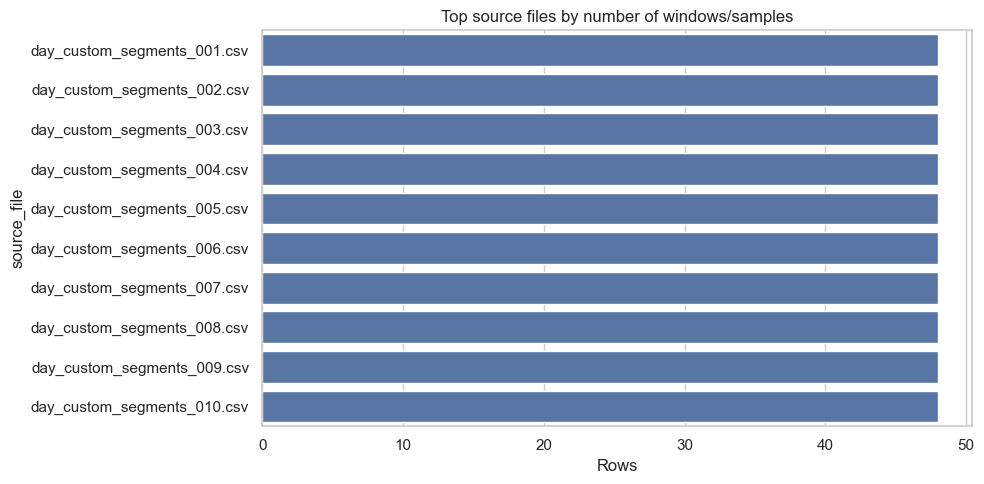

Saved quality report: reports\quality_report_train.json


In [9]:
# Data quality checks for debugging low-score issues
quality_report = {
    "n_samples": int(len(features_df)),
    "n_features_total": int(features_df.shape[1]),
    "n_unique_source_files": int(features_df["source_file"].nunique()) if "source_file" in features_df.columns else None,
    "label_distribution": features_df["label"].value_counts(dropna=False).sort_index().to_dict(),
}

if "label" in features_df.columns:
    label_count = features_df["label"].value_counts()
    quality_report["imbalance_ratio_max_to_min"] = float(label_count.max() / max(label_count.min(), 1))
    if "source_file" in features_df.columns:
        src_per_label = features_df.groupby("label")["source_file"].nunique().sort_index().to_dict()
        quality_report["unique_sources_per_label"] = {int(k): int(v) for k, v in src_per_label.items()}

numeric_cols = features_df.select_dtypes(include=[np.number]).columns.tolist()
if numeric_cols:
    null_ratio = features_df[numeric_cols].isna().mean().sort_values(ascending=False)
    quality_report["top10_null_ratio"] = {k: float(v) for k, v in null_ratio.head(10).items()}

if "X_train_model" in globals() and "y_train_model" in globals():
    quality_report["train_samples_for_modeling"] = int(len(X_train_model))
    quality_report["train_class_distribution_for_modeling"] = pd.Series(y_train_model).value_counts(dropna=False).sort_index().to_dict()
if "n_synth_created" in globals():
    quality_report["synthetic_samples_added"] = int(n_synth_created)

print("=== Quality Report ===")
for k, v in quality_report.items():
    print(f"{k}: {v}")

if "source_file" in features_df.columns:
    src_counts = features_df["source_file"].value_counts().head(15)
    plt.figure(figsize=(10, 5))
    sns.barplot(x=src_counts.values, y=src_counts.index, orient="h")
    plt.title("Top source files by number of windows/samples")
    plt.xlabel("Rows")
    plt.ylabel("source_file")
    plt.tight_layout()
    plt.show()

report_path = REPORTS_DIR / "quality_report_train.json"
pd.Series({k: str(v) for k, v in quality_report.items()}).to_json(report_path, force_ascii=False, indent=2)
print(f"Saved quality report: {report_path}")

In [10]:
# Quick summary after training
if 'results_df' in globals() and isinstance(results_df, pd.DataFrame):
    cols = ['model', 'accuracy', 'f1_weighted', 'f1_macro', 'train_seconds', 'cv_best_score', 'best_params']
    cols = [c for c in cols if c in results_df.columns]
    print('Model results (KNN, Logistic, LDA, RandomForest, SVM):')
    display(results_df[cols].head(10))
else:
    print('results_df not available yet. Run Cell 7 first.')

Model results (KNN, Logistic, LDA, RandomForest, SVM):


,model,accuracy,f1_weighted,f1_macro,train_seconds,cv_best_score,best_params
0,RandomForest,0.916667,0.916889,0.915238,5.67,0.8792,"{'model__max_depth': 20, 'model__max_features'..."
1,LogisticRegression,0.812500,0.818466,0.783751,0.80,0.8082,"{'model__C': 8.0, 'model__solver': 'lbfgs', 'p..."
2,KNN_basic,0.770833,0.782370,0.734812,5.67,0.8291,"{'model__metric': 'minkowski', 'model__n_neigh..."
3,SVM_linear,0.770833,0.774158,0.746261,0.16,0.8375,{'model__C': 1.0}
4,LDA,0.729167,0.738163,0.686201,0.07,0.8262,"{'model__shrinkage': 'auto', 'model__solver': ..."


## Part B — Deep Learning on Pointcaré grid
- Dùng Pointcaré grid (30×30) xuất từ Part 1 (`.npz`) để train mô hình deep learning.
- Nếu có `torch` sẽ chạy CNN; nếu chưa có sẽ fallback sang `MLPClassifier` (một baseline DL đơn giản).

In [12]:
# Pointcaré -> Deep Learning baseline (loaded from Part 1 export)
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import GroupShuffleSplit, StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


POINTCARE_DIR = FEATURE_DIR / "pointcare"
PC_BASENAME = "day_scenarios_w1800_grid30_rr400to1400"
PC_NPZ = POINTCARE_DIR / f"{PC_BASENAME}.npz"
PC_META = POINTCARE_DIR / f"{PC_BASENAME}_meta.csv"

if not PC_NPZ.exists():
    raise FileNotFoundError(
        f"Missing Pointcaré export: {PC_NPZ}.\n"
        "Run the export cell in train_part1_features.ipynb first."
    )

pc = np.load(PC_NPZ, allow_pickle=True)
X_pc = pc["X"].astype(np.float32)  # (N, 900) flattened 30x30
y_pc = pc["y"].astype(int)
g_pc = pc["groups"].astype(str)

print("=== Pointcaré dataset loaded ===")
print("X_pc:", X_pc.shape, "dtype:", X_pc.dtype)
print("Label distribution:")
print(pd.Series(y_pc).value_counts().sort_index())
print("Unique groups:", pd.Series(g_pc).nunique())
if PC_META.exists():
    meta_df = pd.read_csv(PC_META)
    print("Meta rows:", len(meta_df), "columns:", list(meta_df.columns))

if len(np.unique(y_pc)) < 2:
    raise ValueError("Pointcaré dataset has <2 classes; cannot train.")

# Keep the same split style as ML section: group-aware split by source_file
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(X_pc, y_pc, groups=g_pc))
X_tr, X_te = X_pc[tr_idx], X_pc[te_idx]
y_tr, y_te = y_pc[tr_idx], y_pc[te_idx]

n_classes = int(pd.Series(y_pc).nunique())

# ------------------------------------------------------------
# Option 1 (preferred): PyTorch CNN on 30x30 grid
# ------------------------------------------------------------
use_torch = False
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    use_torch = True
except Exception as ex:
    print("PyTorch not available -> fallback to scikit-learn MLPClassifier.")
    print("To install PyTorch (CPU): pip install torch")
    print("Import error:", ex)

if use_torch:
    def set_all_seeds(seed: int) -> None:
        import random
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)

    set_all_seeds(RANDOM_STATE)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print("Device:", device)

    # Reshape to (N, 1, 30, 30)
    def to_grid(x_flat: np.ndarray) -> np.ndarray:
        if x_flat.shape[1] != 900:
            raise ValueError(f"Expected 900 dims for 30x30 grid; got {x_flat.shape}")
        return x_flat.reshape(-1, 1, 30, 30)

    X_tr_grid = to_grid(X_tr)
    X_te_grid = to_grid(X_te)

    # Train/val split inside train set (stratified)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=RANDOM_STATE)
    tr2_idx, va_idx = next(sss.split(X_tr_grid, y_tr))
    X_tr2, y_tr2 = X_tr_grid[tr2_idx], y_tr[tr2_idx]
    X_va, y_va = X_tr_grid[va_idx], y_tr[va_idx]

    train_ds = TensorDataset(torch.from_numpy(X_tr2), torch.from_numpy(y_tr2))
    val_ds = TensorDataset(torch.from_numpy(X_va), torch.from_numpy(y_va))
    test_ds = TensorDataset(torch.from_numpy(X_te_grid), torch.from_numpy(y_te))

    batch_size = 64
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

    # Class weights (handle imbalance)
    counts = pd.Series(y_tr2).value_counts().sort_index()
    weights = (counts.sum() / counts).values.astype(np.float32)
    class_weight = torch.tensor(weights, dtype=torch.float32, device=device)

    class PoincareCNN(nn.Module):
        def __init__(self, n_out: int):
            super().__init__()
            self.net = nn.Sequential(
                nn.Conv2d(1, 16, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),  # 15x15
                nn.Conv2d(16, 32, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(2),  # 7x7
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1)),
            )
            self.head = nn.Linear(64, n_out)

        def forward(self, x):
            x = x.float()
            x = self.net(x)
            x = x.view(x.size(0), -1)
            return self.head(x)

    model = PoincareCNN(n_classes).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    def run_epoch(loader, train: bool):
        model.train(train)
        total_loss = 0.0
        all_pred = []
        all_true = []
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += float(loss.item()) * xb.size(0)
            all_pred.append(torch.argmax(logits, dim=1).detach().cpu().numpy())
            all_true.append(yb.detach().cpu().numpy())
        y_pred = np.concatenate(all_pred) if all_pred else np.array([], dtype=int)
        y_true = np.concatenate(all_true) if all_true else np.array([], dtype=int)
        avg_loss = total_loss / max(len(loader.dataset), 1)
        acc = accuracy_score(y_true, y_pred) if len(y_true) else np.nan
        f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0) if len(y_true) else np.nan
        return avg_loss, acc, f1w

    best_val = -1.0
    best_state = None
    patience = 6
    patience_left = patience
    max_epochs = 40

    print("\n=== Pointcaré Deep Learning (PyTorch CNN) ===")
    for epoch in range(1, max_epochs + 1):
        tr_loss, tr_acc, tr_f1w = run_epoch(train_loader, train=True)
        va_loss, va_acc, va_f1w = run_epoch(val_loader, train=False)
        print(f"Epoch {epoch:02d} | train loss {tr_loss:.4f} f1w {tr_f1w:.4f} | val loss {va_loss:.4f} f1w {va_f1w:.4f}")
        if va_f1w > best_val + 1e-4:
            best_val = float(va_f1w)
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_left = patience
        else:
            patience_left -= 1
            if patience_left <= 0:
                print("Early stopping.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)

    # Evaluate on test
    model.eval()
    y_pred_list = []
    y_true_list = []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            y_pred_list.append(torch.argmax(logits, dim=1).cpu().numpy())
            y_true_list.append(yb.numpy())
    y_pred = np.concatenate(y_pred_list)
    y_true = np.concatenate(y_true_list)

    dl_acc = accuracy_score(y_true, y_pred)
    dl_f1w = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    dl_f1m = f1_score(y_true, y_pred, average="macro", zero_division=0)

    print("\n=== Test metrics (Pointcaré CNN) ===")
    print("accuracy:", round(dl_acc, 4))
    print("f1_weighted:", round(dl_f1w, 4))
    print("f1_macro:", round(dl_f1m, 4))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, zero_division=0))

    # Save model checkpoint (optional)
    ckpt_path = ARTIFACTS_DIR / f"poincare_cnn_{PC_BASENAME}.pt"
    torch.save({"state_dict": model.state_dict(), "n_classes": n_classes, "basename": PC_BASENAME}, ckpt_path)
    print("Saved:", ckpt_path)

else:
    # ------------------------------------------------------------
    # Option 2 (fallback): scikit-learn MLP on flattened 900-dim grid
    # ------------------------------------------------------------
    from sklearn.neural_network import MLPClassifier

    print("\n=== Pointcaré Deep Learning (fallback: MLPClassifier) ===")
    mlp = Pipeline([
        ("scaler", StandardScaler(with_mean=False)),
        ("clf", MLPClassifier(
            hidden_layer_sizes=(256, 128),
            activation="relu",
            alpha=1e-4,
            learning_rate_init=1e-3,
            max_iter=200,
            early_stopping=True,
            random_state=RANDOM_STATE,
        )),
    ])
    mlp.fit(X_tr, y_tr)
    y_pred = mlp.predict(X_te)

    dl_acc = accuracy_score(y_te, y_pred)
    dl_f1w = f1_score(y_te, y_pred, average="weighted", zero_division=0)
    dl_f1m = f1_score(y_te, y_pred, average="macro", zero_division=0)

    print("\n=== Test metrics (Pointcaré MLP) ===")
    print("accuracy:", round(dl_acc, 4))
    print("f1_weighted:", round(dl_f1w, 4))
    print("f1_macro:", round(dl_f1m, 4))
    print("\nClassification report:")
    print(classification_report(y_te, y_pred, zero_division=0))


# Side-by-side: best engineered-feature model from Part A (if ran)
if "results_df" in globals() and isinstance(results_df, pd.DataFrame) and not results_df.empty:
    best_row = results_df.iloc[0].to_dict()
    print("\n=== Engineered-feature best model (from this notebook run) ===")
    print({k: best_row.get(k) for k in ["model", "accuracy", "f1_weighted", "f1_macro", "cv_best_score"] if k in best_row})

# Optional: check overlap of source_file between engineered features and Pointcaré
if "features_df" in globals() and isinstance(features_df, pd.DataFrame) and "source_file" in features_df.columns:
    overlap = set(features_df["source_file"].astype(str)).intersection(set(pd.Series(g_pc).astype(str)))
    print("\nEngineered/Pointcaré source_file overlap:", len(overlap))
    if overlap:
        print("Example overlap:", sorted(list(overlap))[:5])

=== Pointcaré dataset loaded ===
X_pc: (480, 900) dtype: float32
Label distribution:
0    218
1    124
2     76
3     62
Name: count, dtype: int64
Unique groups: 10
Meta rows: 480 columns: ['source_file', 'window_id', 'start_time', 'end_time', 'label']
PyTorch not available -> fallback to scikit-learn MLPClassifier.
To install PyTorch (CPU): pip install torch
Import error: No module named 'torch'

=== Pointcaré Deep Learning (fallback: MLPClassifier) ===

=== Test metrics (Pointcaré MLP) ===
accuracy: 0.6562
f1_weighted: 0.661
f1_macro: 0.5788

Classification report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82        46
           1       0.79      0.48      0.59        23
           2       0.50      0.41      0.45        17
           3       0.33      0.70      0.45        10

    accuracy                           0.66        96
   macro avg       0.61      0.60      0.58        96
weighted avg       0.70      0.66      0.66   